Saving 0000.csv to 0000.csv
Dataset shape: (32399, 12)
✅ One-Class SVM trained successfully!


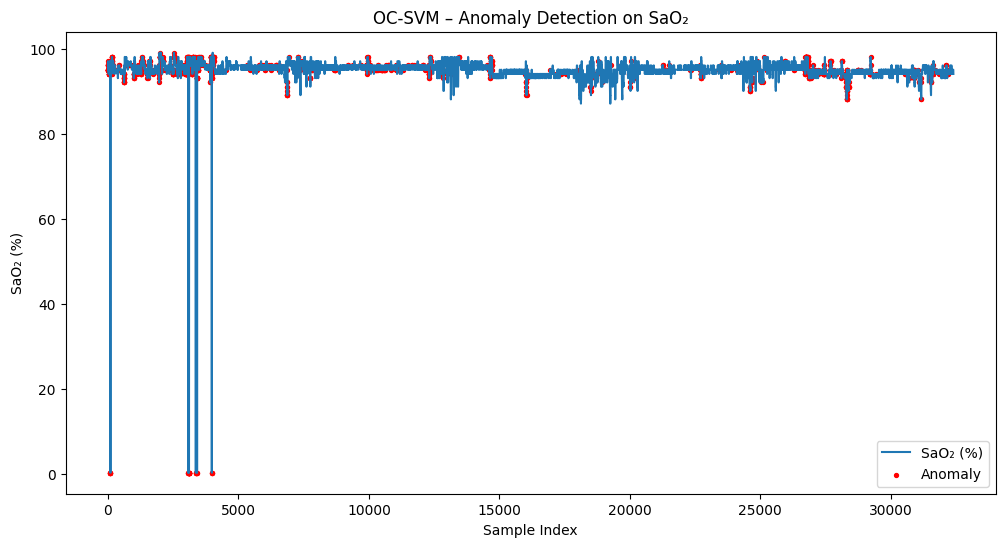

Total anomalies detected: 1621
Percentage anomalies: 5.00%
✅ Model and scaler saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import joblib

from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
df.head()

df = df.select_dtypes(include=[np.number])
df = df.fillna(df.mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)
ocsvm.fit(X_scaled)

print("✅ One-Class SVM trained successfully!")


y_pred = ocsvm.predict(X_scaled)     
df['anomaly'] = np.where(y_pred == -1, 1, 0)

if 'SaO2' in df.columns:
    plt.figure(figsize=(12,6))
    plt.title("OC-SVM – Anomaly Detection on SaO₂")
    plt.plot(df.index, df['SaO2'], label='SaO₂ (%)')
    plt.scatter(df.index[df['anomaly']==1],
                df['SaO2'][df['anomaly']==1],
                color='red', s=8, label='Anomaly')
    plt.xlabel("Sample Index"); plt.ylabel("SaO₂ (%)"); plt.legend(); plt.show()

print("Total anomalies detected:", df['anomaly'].sum())
print("Percentage anomalies: {:.2f}%".format(100 * df['anomaly'].sum() / len(df)))

joblib.dump(ocsvm, "one_class_svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model and scaler saved successfully!")

from google.colab import files
files.download("one_class_svm_model.pkl")
files.download("scaler.pkl")
